***Objective***

Analyze daily price data for Reliance Industries Limited (RELIANCE.NS) using Python
and libraries such as numpy, pandas, matplotlib, and yfinance. The data to be used
for the assignment has to be the daily data for the past 2 years.

***Tasks***

1. Identify Significant Price Changes:
Find the five highest single-day percentage price changes in the stock’s history.
Annotate these points on the daily closing price chart.

[*********************100%***********************]  1 of 1 completed


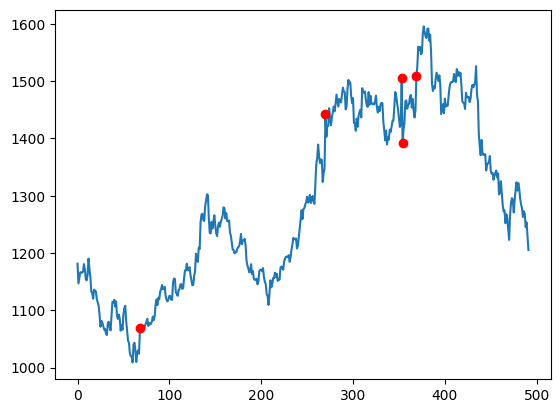

In [29]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

ticker = "RELIANCE.NS"

data = yf.download(ticker, start = '2022-12-22', end = '2024-12-22')
print()

length = len(data.index)

change = [0]
for i in range (1,length):
  a = float(data.iloc[i]['Adj Close'][ticker])
  b = float(data.iloc[i-1]['Adj Close'][ticker])
  chng = (a-b)*100/b
  change.append(chng)

indices = list(range(length))

data['Index'] = indices
data['Percentage Change'] = change
#print(data)

change1 = [abs(var) for var in change]
sorted_change = sorted(change1, reverse = True)
highest=[]
for i in range (0,5):
  a = sorted_change[i]
  highest.append(a)

#print(highest)

ypoints = np.array(data['Adj Close'])
plt.plot(ypoints)
highpointsadjclose = []
highpointsdates = []
for i in highest:
  x = float(data.loc[abs(data['Percentage Change'])==i]['Adj Close'][ticker].iloc[0])
  y = int(data.loc[abs(data['Percentage Change'])==i]['Index'].iloc[0])
  highpointsadjclose.append(x)
  highpointsdates.append(y)
highpointsy = np.array(highpointsadjclose)
highpointsx = np.array(highpointsdates)
plt.plot(highpointsx, highpointsy, 'o', mfc='r', mec = 'r')
plt.show()






2. Simple Moving Averages (SMA):
 Plot the daily closing price data. Overlay the chart with the 50-day and 200-day
 simple moving averages (SMA).

[*********************100%***********************]  1 of 1 completed


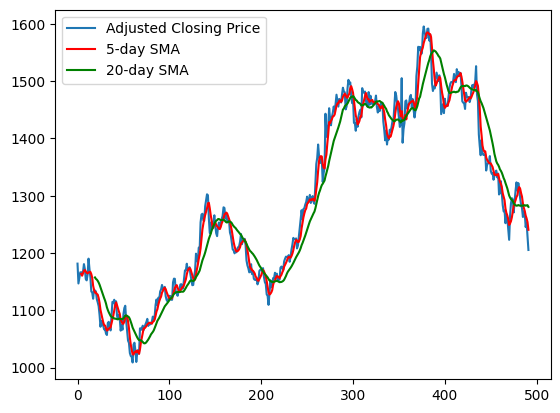

In [28]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

ticker = "RELIANCE.NS"

data = yf.download(ticker, start = '2022-12-22', end = '2024-12-22')
print()

length = len(data.index)

indices = list(range(length))

data['Index'] = indices

sma_5day = []
for i in range (4,length):
  sumbox=[]
  for j in range (0,5):
    a = float(data.iloc[i-j]['Adj Close'][ticker])
    sumbox.append(a)
  sma = (sum(sumbox))/5
  sma_5day.append(sma)
data_sma_5day = [0,0,0,0]
data_sma_5day.extend(sma_5day)

data['5-day SMA'] = data_sma_5day

sma_20day = []
for i in range (19,length):
  sumbox=[]
  for j in range (0,20):
    a = float(data.iloc[i-j]['Adj Close'][ticker])
    sumbox.append(a)
  sma = (sum(sumbox))/20
  sma_20day.append(sma)
data_sma_20day = [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]
data_sma_20day.extend(sma_20day)

data['20-day SMA'] = data_sma_20day

#print(data)

ypoints = np.array(data['Adj Close'])
plt.plot(ypoints, label = 'Adjusted Closing Price')

sma5daydates = []
for i in sma_5day:
  y = int(data.loc[data['5-day SMA']==i]['Index'].iloc[0])
  sma5daydates.append(y)

sma5dayx = np.array(sma5daydates)
plt.plot(sma5daydates, sma_5day, label = '5-day SMA', c = 'r')

sma20daydates = []
for i in sma_20day:
  y = int(data.loc[data['20-day SMA']==i]['Index'].iloc[0])
  sma20daydates.append(y)

sma20dayx = np.array(sma20daydates)
plt.plot(sma20daydates, sma_20day, label = '20-day SMA', c = 'g')
plt.legend(loc = 'upper left')
plt.show()


3. Candlestick Chart:
 Using yfinance, fetch daily stock price data for the last two years. Plot the Open,
 High, Low, and Close (OHLC) values as a candlestick chart.

[*********************100%***********************]  1 of 1 completed


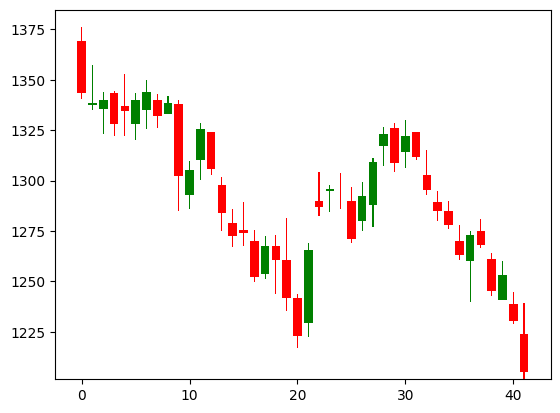

In [27]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

ticker = "RELIANCE.NS"

data = yf.download(ticker, start = '2024-10-22', end = '2024-12-22')
print()

length = len(data.index)

indices = list(range(length))

data['Index'] = indices
#print(data)

green=[]
red=[]

for i in range (0,length):
  if float(data.iloc[i]['Close'][ticker]) >= float(data.iloc[i]['Open'][ticker]):
    green.append(int(data.iloc[i]['Index'].iloc[0]))
  else:
    red.append(int(data.iloc[i]['Index'].iloc[0]))

openred = []
closered = []
highred = []
lowred = []

for i in red:
  openred.append(float(data.iloc[i]['Open'][ticker]))
  closered.append(float(data.iloc[i]['Close'][ticker]))
  highred.append(float(data.iloc[i]['High'][ticker]))
  lowred.append(float(data.iloc[i]['Low'][ticker]))

opengreen = []
closegreen = []
highgreen = []
lowgreen = []

for i in green:
  opengreen.append(float(data.iloc[i]['Open'][ticker]))
  closegreen.append(float(data.iloc[i]['Close'][ticker]))
  highgreen.append(float(data.iloc[i]['High'][ticker]))
  lowgreen.append(float(data.iloc[i]['Low'][ticker]))

xpointsgreen=np.array(green)
xpointsred=np.array(red)
#Ignore these statements
#plt.bar(xpointsgreen, np.array(highgreen), color='g',width = 0.1)
#plt.bar(xpointsgreen, np.array(closegreen), color='g', width = 1)
#plt.bar(xpointsgreen, np.array(opengreen), color='w', width = 1)
#plt.bar(xpointsgreen, np.array(opengreen), color='g', width = 0.1)
#plt.bar(xpointsgreen, np.array(lowgreen), color='w',width = 0.1)
#plt.bar(xpointsred, np.array(highred), color='r',width = 0.1)
#plt.bar(xpointsred, np.array(openred), color='r', width = 1)
#plt.bar(xpointsred, np.array(closered), color='w', width = 1)
#plt.bar(xpointsred, np.array(closered), color='r', width = 0.1)
#plt.bar(xpointsred, np.array(lowred), color='w',width = 0.1)

plt.bar(xpointsgreen,np.array(closegreen)-np.array(opengreen),bottom=np.array(opengreen), color='g', width=0.8)
plt.bar(xpointsgreen,np.array(highgreen)-np.array(lowgreen),bottom=np.array(lowgreen), color='g', width=0.1)
plt.bar(xpointsred,np.array(closered)-np.array(openred),bottom=np.array(openred), color='r', width=0.8)
plt.bar(xpointsred,np.array(highred)-np.array(lowred),bottom=np.array(lowred), color='r', width=0.1)
plt.show()

#Candlesticks not visible due to large number of dates in dataframe, use dataframe with fewer dates for clear view


4. Gap Up and Gap Down Days:
 Write a program to identify all “gap up” and “gap down” days in the stock’s daily
 price data. Label these points on the closing price chart.

[*********************100%***********************]  1 of 1 completed


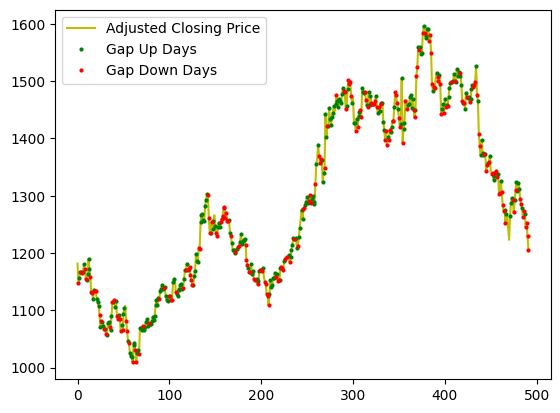

In [26]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

ticker = "RELIANCE.NS"

data = yf.download(ticker, start = '2022-12-22', end = '2024-12-22')
print()

length = len(data.index)

indices = list(range(length))

data['Index'] = indices
#print(data)

gapup=[]
gapdown=[]

for i in range (1,length):
  if float(data.iloc[i]['Open'][ticker])>float(data.iloc[i-1]['Close'][ticker]):
    gapup.append(int(data.iloc[i]['Index'].iloc[0]))
  if float(data.iloc[i]['Open'][ticker])<float(data.iloc[i-1]['Close'][ticker]):
    gapdown.append(int(data.iloc[i]['Index'].iloc[0]))

ypoints = np.array(data['Adj Close'])
plt.plot(ypoints, label = 'Adjusted Closing Price', c = 'y')

gapupadjclose = []
for i in gapup:
  x = float(data.iloc[i]['Adj Close'][ticker])
  gapupadjclose.append(x)
gapupy = np.array(gapupadjclose)
gapupx = np.array(gapup)
plt.plot(gapupx, gapupy, 'o', mfc='g', mec = 'g', label = 'Gap Up Days', ms = 2)

gapdownadjclose = []
for i in gapdown:
  x = float(data.iloc[i]['Adj Close'][ticker])
  gapdownadjclose.append(x)
gapdowny = np.array(gapdownadjclose)
gapdownx = np.array(gapdown)
plt.plot(gapdownx, gapdowny, 'o', mfc='r', mec = 'r', label = 'Gap Down Days', ms = 2)
plt.legend(loc = 'upper left')
plt.show()


 5. Intraday VWAP Calculation:
 Fetch intraday price and volume data for the stock. Compute the Volume Weighted
 Average Price (VWAP) and overlay it on the intraday price chart.

[*********************100%***********************]  1 of 1 completed


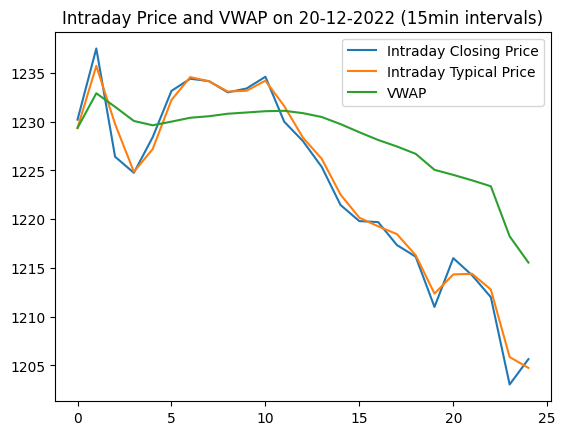

In [24]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime

ticker = "RELIANCE.NS"

data = yf.download(ticker, period = '5d', interval='15m', start = '2024-12-20', end = '2024-12-22')
print()

length = len(data.index)

indices = list(range(length))

data['Index'] = indices



typicprices=[]
volumextypicals=[]
for i in range(0,length):
  high=float(data.iloc[i]['High'][ticker])
  low=float(data.iloc[i]['Low'][ticker])
  close=float(data.iloc[i]['Close'][ticker])
  volume=float(data.iloc[i]['Volume'][ticker])
  typical=(high+low+close)/3
  volumextypical=typical*volume
  typicprices.append(typical)
  volumextypicals.append(volumextypical)

data['Typical Price']=typicprices
data['Volume * Typical Price']=volumextypicals

vwaps=[]
for i in range(0,length):
  set1=[]
  set2=[]
  for j in range (0,i+1):
    vtp = float(data.iloc[j]['Volume * Typical Price'].iloc[0])
    volume=float(data.iloc[j]['Volume'][ticker])
    set1.append(vtp)
    set2.append(volume)
  cumvtp=sum(set1)
  cumvolume=sum(set2)
  vwap=cumvtp/cumvolume
  vwaps.append(vwap)

data['VWAP']=vwaps
#print(data)

ypoints = np.array(data['Close'])
plt.plot(ypoints, label = 'Intraday Closing Price')

ypoints1 = np.array(data['Typical Price'])
plt.plot(ypoints1, label = 'Intraday Typical Price')

ypoints2 = np.array(data['VWAP'])
plt.plot(ypoints2, label = 'VWAP')

plt.title('Intraday Price and VWAP on 20-12-2022 (15min intervals)')
plt.legend(loc='upper right')
plt.show()




6. Return Analysis:
 Compute the absolute values of daily stock returns. Visualize the distribution of
 these returns.

[*********************100%***********************]  1 of 1 completed


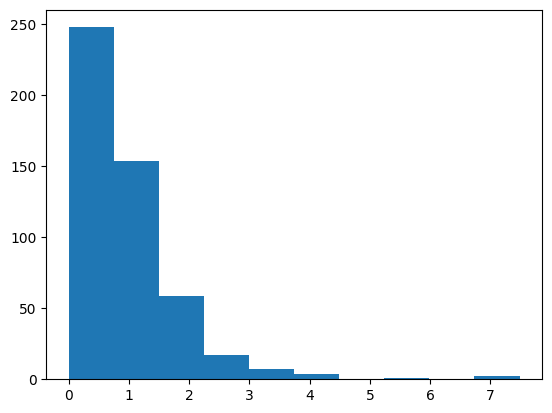

In [25]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

ticker = "RELIANCE.NS"

data = yf.download(ticker, start = '2022-12-22', end = '2024-12-22')
print()

length = len(data.index)

change = [0]
for i in range (1,length):
  a = float(data.iloc[i]['Close'][ticker])
  b = float(data.iloc[i-1]['Close'][ticker])
  chng = (a-b)*100/b
  change.append(chng)

indices = list(range(length))

data['Index'] = indices
data['Daily Return'] = change
#print(data)

change1 = [abs(var) for var in change]

ypoints = np.array(change1)
plt.hist(ypoints)
plt.show()